<a href="https://colab.research.google.com/github/rocketwolf98/ColabCompilation/blob/main/notebooks/1.0-random-useless-facts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Useless Facts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iragca/pit-predictive-analysis/blob/master/notebooks/1.0-random-useless-facts.ipynb)

## Executive Summary



## Table of Contents

```bash
.
├── Title Section
│       ├── Executive Summary
│       ├── Table of Contents                   #  ⭐ You are here
│       └── Setup                               #  Libraries and dataset imports
├── Introduction
│       ├── Problem Statement
└── Methodology
```


## Setup

Before running this notebook make sure to have environment variables set: `SUPABASE_URL` and `SUPABASE_KEY`.


In [1]:
try:
    import google.colab  # type: ignore
    IS_COLAB_ENVIRONMENT = True
except ImportError:
    IS_COLAB_ENVIRONMENT = False

if IS_COLAB_ENVIRONMENT:
    from google.colab import userdata # type: ignore
    %pip install iragca
    %pip install pydantic
    %pip install supabase

In [20]:
from enum import Enum
import os
from urllib.parse import urlencode, urljoin

import dotenv
import httpx
from pydantic import BaseModel
from supabase import Client, create_client

dotenv.load_dotenv()

False

# Introduction

## Problem Statement

What are the most common topics being observed despite the mundaneness of the subject matter?

# Methodology

## API Wrapper

In [21]:
from typing import Optional


class Language(str, Enum):
    """
    Enumeration of supported languages for the Random Useless Facts API.

    Each enum member corresponds to the language code expected by the
    remote API.
    """
    ENGLISH = "en"
    GERMAN = "de"

class Fact(BaseModel):
    """
    Data model representing a response returned by the Random Useless Facts API.

    Parameters
    ----------
    id : str
        Unique identifier of the fact.
    text : str
        The textual content of the fact.
    source : str
        Origin or reference for the fact.
    source_url : str
        URL pointing to the source.
    language : Language
        Language in which the fact is written.
    permalink : str
        Permanent URL for accessing the fact.

    Notes
    -----
    This model is parsed from JSON using Pydantic and ensures type validation
    of the incoming API response.
    """
    id: str
    text: str
    source: str
    source_url: str
    language: Language
    permalink: str

    def __hash__(self) -> int:
        return hash(self.id)


class RandomUselessFactAPI:
    """
    Client for interacting with the Random Useless Facts API.

    Parameters
    ----------
    base_url : str, optional
        Base URL of the API. Defaults to ``"https://uselessfacts.jsph.pl/"``.

    Notes
    -----
    This class exposes convenience methods to construct API URLs and retrieve
    random facts in various languages. Requests are executed using ``httpx``.
    """
    def __init__(self, base_url: str ="https://uselessfacts.jsph.pl/") -> None:
        self.base_url = base_url

    def get_random_fact(self, language: Language = Language.ENGLISH) -> Fact:
        """
        Retrieve a random useless fact.

        Parameters
        ----------
        language : Language, optional
            Language in which the fact should be returned. Defaults to
            ``Language.ENGLISH``.

        Returns
        -------
        Response
            Parsed API response containing the random fact.

        Raises
        ------
        httpx.HTTPError
            If the request fails or returns an error status code.

        Examples
        --------
        >>> api = RandomUselessFactAPI()
        >>> fact = api.get_random_fact()
        >>> fact.text
        'Banging your head against a wall for one hour burns 150 calories.'
        """
        url = self._build_random_fact_url(language)
        response = httpx.get(url)
        response.raise_for_status()
        data = response.json()

        return Fact(**data)

    def _build_random_fact_url(self, language: Optional[Language] = None) -> str:
        """
        Construct the request URL for fetching a random fact.

        Parameters
        ----------
        language : Optional[Language], optional
            Language code to include as a query parameter. Defaults to
            ``None``.

        Returns
        -------
        str
            Fully constructed URL pointing to the random fact endpoint.

        Notes
        -----
        This method is internal and is not intended to be called directly by
        users. It performs safe URL joining and query parameter encoding.
        """
        ENDPOINT = "api/v2/facts/random"
        path = urljoin(self.base_url, ENDPOINT)

        if language is not None:
            params = urlencode({"language": language.value})
            return f"{path}?{params}"
        return path


# Data Warehouse

In [22]:
from functools import lru_cache
from supabase import create_client, Client

class SupabaseStorage:
    """
    Storage interface for interacting with the Supabase `facts` table.

    This class handles:
    - Environment variable loading for Supabase credentials
    - Inserting single or multiple facts into the database
    - Retrieving all stored facts

    Attributes
    ----------
    supabase : supabase.Client
        Initialized Supabase client used for database operations.

    Raises
    ------
    ValueError
        If required Supabase environment variables are missing.
    """
    def __init__(self) -> None:
        """
        Initialize the Supabase client using environment variables.

        The method attempts to load the Supabase URL and API key using
        `load_env`. If either value is missing, an exception is raised.

        Raises
        ------
        ValueError
            If `SUPABASE_URL` or `SUPABASE_KEY` is not set.
        """
        env = self.load_env()
        if env and all(env.values()):
            self.supabase: Client = create_client(env["url"], env["key"])
        else:
            raise ValueError("SUPABASE_URL and SUPABASE_KEY must be set in environment variables.")

    @lru_cache
    def insert_fact(self, fact: Fact):
        """
        Insert a single fact into the Supabase `facts` table.

        This method is cached with an LRU cache of size 1.

        Parameters
        ----------
        fact : Fact
            The fact object to be inserted into the database.

        Returns
        -------
        supabase.lib.client_response.ClientResponse
            Response object returned by the Supabase insert operation.
        """
        response = self.supabase.table("facts").insert(fact.model_dump()).execute()
        return response

    def insert_facts(self, facts: list[Fact]):
        """
        Insert multiple facts into the Supabase `facts` table.

        Parameters
        ----------
        facts : list of Fact
            A list of fact objects to be inserted.

        Returns
        -------
        supabase.lib.client_response.ClientResponse
            Response object returned by the Supabase bulk insert operation.
        """
        response = self.supabase.table("facts").insert([fact.model_dump() for fact in facts]).execute()
        return response

    def get_all_facts(self) -> list[Fact]:
        """
        Retrieve all facts from the Supabase `facts` table.

        Returns
        -------
        list of Fact
            A list of `Fact` objects reconstructed from the database records.
        """
        response = self.supabase.table("facts").select("*").execute()
        data = response.data
        return [Fact(**item) for item in data]

    def get_english_facts(self) -> list[Fact]:
        """
        Retrieve only English facts from the Supabase `facts` table.

        Returns
        -------
        list of Fact
            A list of `Fact` objects reconstructed from the database records
            where the language is English.
        """
        response = self.supabase.table("facts").select("*").eq("language", Language.ENGLISH.value).execute()
        data = response.data
        return [Fact(**item) for item in data]

    @staticmethod
    def load_env():
        """
        Load Supabase environment variables.

        This method supports both Google Colab and standard local
        environment variable loading.

        Returns
        -------
        dict
            Dictionary containing:
            - `"url"` : str
                Supabase project URL.
            - `"key"` : str
                Supabase API key.
        """
        if IS_COLAB_ENVIRONMENT:
            url: str = userdata.get("SUPABASE_URL")
            key: str = userdata.get("SUPABASE_KEY")
        else:
            url: str = os.environ.get("SUPABASE_URL", "")
            key: str = os.environ.get("SUPABASE_KEY", "")
        return {"url": url, "key": key}

# Ingesting data

In [23]:
api = RandomUselessFactAPI()
storage = SupabaseStorage()

In [24]:
fact: Fact = api.get_random_fact(language=Language.ENGLISH)
print(fact.text)

There are no words in the dictionary that rhyme with orange, purple, silver and month.


In [25]:
fact

Fact(id='ea5a50f40a129835e3e747fc7d554bb2', text='There are no words in the dictionary that rhyme with orange, purple, silver and month.', source='djtech.net', source_url='https://www.djtech.net/humor/shorty_useless_facts.htm', language=<Language.ENGLISH: 'en'>, permalink='https://uselessfacts.jsph.pl/api/v2/facts/ea5a50f40a129835e3e747fc7d554bb2')

In [26]:
from tqdm import tqdm
from itertools import batched
from time import sleep as cooldown
from itertools import chain

FETCH_COUNT = 100
BATCH_SIZE = 10


def fetch_facts(count: int, cooldown_sec: int = 1) -> list[Fact]:
    facts = []
    for _ in tqdm(range(count), desc="Fetching facts"):
        fact = api.get_random_fact(language=Language.ENGLISH) #Parse facts only in English
        facts.append(fact)
        cooldown(cooldown_sec)  # To avoid hitting rate limits
    return facts

# Fetch facts from the API
facts = fetch_facts(FETCH_COUNT)

failed_batches = []

# Insert facts into Supabase in batches
for batch in tqdm(batched(facts, BATCH_SIZE), total=FETCH_COUNT / BATCH_SIZE, desc="Batch ingest"):
    try:
        storage.insert_facts(list(batch))
    except Exception as e:
        failed_batches.append(list(batch))


errors = []

# Retry failed inserts individually
if failed_batches:
    failed_batches = chain.from_iterable(failed_batches)
    for fact in tqdm(failed_batches, desc="Retrying failed inserts"):
        try:
            storage.insert_fact(fact)
        except Exception as e:
            errors.append((fact, str(e)))

# Analyze errors for duplicates
duplicate_count = sum(1 for fact, error in errors if "duplicate" in error.lower())
duplicate_count

Fetching facts: 100%|██████████| 100/100 [02:20<00:00,  1.40s/it]
Batch ingest: 100%|██████████| 10/10.0 [00:03<00:00,  2.75it/s]
Retrying failed inserts: 100it [00:27,  3.57it/s]


100

## Data Exploration

In [27]:
facts = storage.get_all_facts()
len(facts)

1501

In [28]:
facts

[Fact(id='a79df1c3d4ee87fa1c6ffb798cb6c3d1', text='Approximately every seven minutes of every day, someone in an aerobics class pulls their hamstring.', source='djtech.net', source_url='http://www.djtech.net/humor/useless_facts.htm', language=<Language.ENGLISH: 'en'>, permalink='https://uselessfacts.jsph.pl/api/v2/facts/a79df1c3d4ee87fa1c6ffb798cb6c3d1'),
 Fact(id='9930af0979d0b01ffa1311000e6cf29c', text='The country code for Russia is "007".', source='djtech.net', source_url='https://www.djtech.net/humor/shorty_useless_facts.htm', language=<Language.ENGLISH: 'en'>, permalink='https://uselessfacts.jsph.pl/api/v2/facts/9930af0979d0b01ffa1311000e6cf29c'),
 Fact(id='38583dc74ede6858ca400242b81efd8d', text='Steely Dan got their name from a sexual device depicted in the book `The Naked Lunch`. \xa0', source='djtech.net', source_url='http://www.djtech.net/humor/useless_facts.htm', language=<Language.ENGLISH: 'en'>, permalink='https://uselessfacts.jsph.pl/api/v2/facts/38583dc74ede6858ca400242

In [38]:
english_facts = storage.get_english_facts()
print(f"Number of English facts: {len(english_facts)}")

Number of English facts: 1001


In [39]:
english_fact_texts = [fact.text for fact in english_facts]

print(f"Total number of English fact texts extracted: {len(english_fact_texts)}")
print("\nFirst 5 extracted fact texts:")
for i, text in enumerate(english_fact_texts[:5]):
    print(f"{text}")

Total number of English fact texts extracted: 1001

First 5 extracted fact texts:
Approximately every seven minutes of every day, someone in an aerobics class pulls their hamstring.
The country code for Russia is "007".
Steely Dan got their name from a sexual device depicted in the book `The Naked Lunch`.  
Human thigh bones are stronger than concrete.
Starfish have no brains.


## Text Preprocessing

In [40]:
!pip install contractions gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.6 MB/s eta 0:00:00


In [45]:
import pandas as pd
import numpy as np

import nltk
import re
from nltk.corpus import stopwords
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
import contractions

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import LdaModel
from sklearn.decomposition import LatentDirichletAllocation

import warnings
warnings.filterwarnings("ignore")

In [54]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [55]:
def preprocess_text(corpus):
  corpus = re.sub(r'[^a-zA-Z\s]', '', corpus.lower())
  tokens = word_tokenize(corpus)
  sw = set(stopwords.words('english'))
  tokens = [word for word in tokens if word not in sw and len(word) > 2]
  stem = WordNetLemmatizer()
  tokens = [stem.lemmatize(word) for word in tokens]
  tokens = [contractions.fix(word) for word in tokens]

  return ' '.join(tokens)

In [59]:
pp_text_eng = [preprocess_text(doc) for doc in english_fact_texts]
pp_text_eng[0:5]

['approximately every seven minute every day someone aerobics class pull hamstring',
 'country code russia',
 'steely dan got name sexual device depicted book naked lunch',
 'human thigh bone stronger concrete',
 'starfish brain']

## Modelling Using Sklearn Latent Dirchlet Allocation (LDA)

In [67]:
cv = CountVectorizer(max_features=128, stop_words='english')
doc_term_matrix = cv.fit_transform(pp_text_eng)

#We can explore 128 out of the 1001 english facts
#We need a reason why but we can narrow down what topics
#Topics that ae quite common but will be reducefd further to the LDA

feature_names = cv.get_feature_names_out()

In [71]:
lda = LatentDirichletAllocation(
    n_components = 4, #number of topics to allocate
    random_state = 98, #for reproducibility
    max_iter = 28
)

lda.fit(doc_term_matrix)

LatentDirichletAllocation(max_iter=28, n_components=4, random_state=98)

In [72]:
for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-5:][::-1]  # Get top 5 words
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Topic 1: word, world, english, language, cat
Topic 2: year, average, people, american, day
Topic 3: state, mile, city, hour, book
Topic 4: time, eye, foot, human, world


In [76]:
pp_text_eng_lda = lda.transform(doc_term_matrix)
df_lda = pd.DataFrame(
    pp_text_eng_lda.round(3),
    columns=[f'Topic {i+1}' for i in range(4)],
    index=[f'Doc {i+1}' for i in range(len(pp_text_eng))]
)
df_lda.T

,Doc 1,Doc 2,Doc 3,Doc 4,Doc 5,Doc 6,Doc 7,Doc 8,Doc 9,Doc 10,Doc 11,Doc 12,Doc 13,Doc 14,Doc 15,Doc 16,Doc 17,Doc 18,Doc 19,Doc 20,Doc 21,Doc 22,Doc 23,Doc 24,Doc 25,Doc 26,Doc 27,Doc 28,Doc 29,Doc 30,Doc 31,Doc 32,Doc 33,Doc 34,Doc 35,Doc 36,Doc 37,Doc 38,Doc 39,Doc 40,...,Doc 962,Doc 963,Doc 964,Doc 965,Doc 966,Doc 967,Doc 968,Doc 969,Doc 970,Doc 971,Doc 972,Doc 973,Doc 974,Doc 975,Doc 976,Doc 977,Doc 978,Doc 979,Doc 980,Doc 981,Doc 982,Doc 983,Doc 984,Doc 985,Doc 986,Doc 987,Doc 988,Doc 989,Doc 990,Doc 991,Doc 992,Doc 993,Doc 994,Doc 995,Doc 996,Doc 997,Doc 998,Doc 999,Doc 1000,Doc 1001
Topic 1,0.067,0.125,0.125,0.083,0.125,0.25,0.083,0.621,0.25,0.25,0.621,0.625,0.125,0.449,0.125,0.129,0.25,0.25,0.125,0.125,0.125,0.25,0.25,0.063,0.25,0.129,0.25,0.45,0.25,0.25,0.125,0.750,0.25,0.25,0.031,0.083,0.083,0.083,0.095,0.417,...,0.625,0.129,0.25,0.084,0.625,0.617,0.125,0.125,0.750,0.083,0.608,0.086,0.064,0.063,0.125,0.050,0.083,0.063,0.625,0.084,0.562,0.25,0.518,0.625,0.809,0.561,0.750,0.063,0.85,0.083,0.063,0.625,0.25,0.129,0.621,0.812,0.125,0.063,0.083,0.806
Topic 2,0.068,0.125,0.125,0.720,0.125,0.25,0.083,0.129,0.25,0.25,0.125,0.125,0.625,0.050,0.625,0.619,0.25,0.25,0.125,0.625,0.125,0.25,0.25,0.063,0.25,0.125,0.25,0.05,0.25,0.25,0.125,0.083,0.25,0.25,0.032,0.083,0.083,0.416,0.083,0.414,...,0.125,0.619,0.25,0.748,0.125,0.127,0.125,0.625,0.083,0.083,0.036,0.319,0.312,0.063,0.125,0.849,0.416,0.312,0.125,0.749,0.312,0.25,0.036,0.125,0.063,0.313,0.083,0.812,0.05,0.416,0.064,0.125,0.25,0.619,0.125,0.063,0.125,0.812,0.416,0.068
Topic 3,0.063,0.125,0.625,0.088,0.625,0.25,0.750,0.125,0.25,0.25,0.125,0.125,0.125,0.451,0.125,0.125,0.25,0.25,0.125,0.125,0.625,0.25,0.25,0.563,0.25,0.617,0.25,0.05,0.25,0.25,0.625,0.083,0.25,0.25,0.031,0.417,0.083,0.083,0.083,0.083,...,0.125,0.125,0.25,0.083,0.125,0.131,0.625,0.125,0.083,0.750,0.036,0.083,0.063,0.812,0.625,0.050,0.083,0.313,0.125,0.083,0.063,0.25,0.036,0.125,0.063,0.064,0.083,0.063,0.05,0.083,0.313,0.125,0.25,0.125,0.125,0.063,0.625,0.063,0.083,0.063
Topic 4,0.803,0.625,0.125,0.108,0.125,0.25,0.083,0.125,0.25,0.25,0.129,0.125,0.125,0.050,0.125,0.127,0.25,0.25,0.625,0.125,0.125,0.25,0.25,0.312,0.25,0.129,0.25,0.45,0.25,0.25,0.125,0.083,0.25,0.25,0.905,0.417,0.750,0.417,0.738,0.086,...,0.125,0.127,0.25,0.084,0.125,0.125,0.125,0.125,0.083,0.083,0.321,0.512,0.562,0.063,0.125,0.050,0.417,0.313,0.125,0.083,0.064,0.25,0.410,0.125,0.066,0.063,0.083,0.063,0.05,0.417,0.561,0.125,0.25,0.127,0.129,0.063,0.125,0.063,0.417,0.063


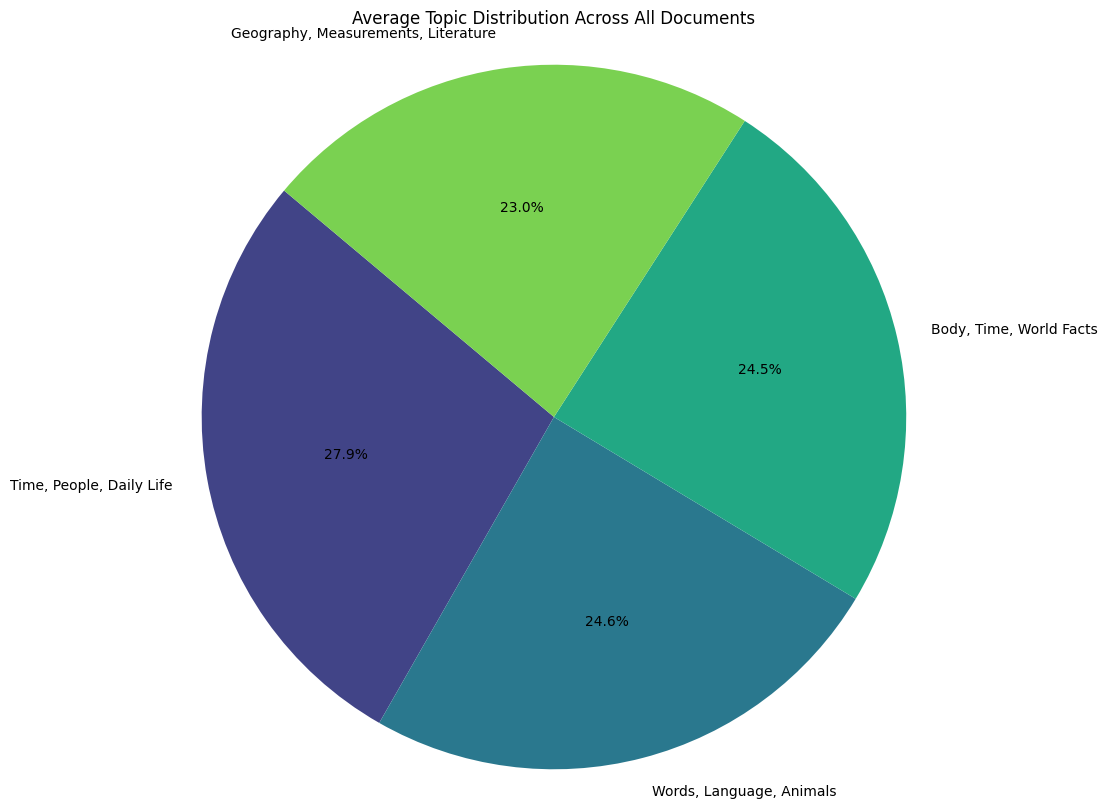

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define new topic names based on top words
new_topic_names = {
    'Topic 1': 'Words, Language, Animals',
    'Topic 2': 'Time, People, Daily Life',
    'Topic 3': 'Geography, Measurements, Literature',
    'Topic 4': 'Body, Time, World Facts'
}

# Map the new names to the average_topic_proportions index
# Using .copy() to avoid SettingWithCopyWarning if average_topic_proportions was a slice
pie_data = average_topic_proportions.rename(index=new_topic_names).copy()

plt.figure(figsize=(10, 10))
plt.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%', # Format percentage display
    startangle=140,
    colors=sns.color_palette('viridis', len(pie_data))
)
plt.title('Average Topic Distribution Across All Documents')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## Using BERTTopic

In [79]:
get_ipython().system('pip install bertopic sentence-transformers umap-learn')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.0 MB/s eta 0:00:00


In [86]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer


In [87]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")

model = BERTopic(embedding_model= embedding_model)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [88]:
topics, probabilities = model.fit_transform(pp_text_eng)
print(f"BERTopic model fitted. Number of topics found: {len(model.get_topics())}")

BERTopic model fitted. Number of topics found: 22


In [91]:
model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,325,-1_every_year_world_one,"[every, year, world, one, per, mile, american,...","[approximately one chicken every human world, ..."
1,0,105,0_state_city_world_largest,"[state, city, world, largest, law, country, il...",[columbia university second largest landowner ...
2,1,79,1_name_invented_named_first,"[name, invented, named, first, disney, john, s...","[name wendy made book peter pan, unusual canno..."
3,2,61,2_average_calorie_brain_eat,"[average, calorie, brain, eat, day, celery, ti...","[average person laugh time day, american avera..."
4,3,56,3_eye_fish_head_water,"[eye, fish, head, water, bird, see, one, dolph...",[dolphin look different direction eye sleep on...
5,4,46,4_word_english_language_letter,"[word, english, language, letter, longest, sen...","[word english language rhyme month, word engli..."
6,5,45,5_ketchup_peanut_tree_cocacola,"[ketchup, peanut, tree, cocacola, apple, plant...",[half food eaten throughout world today develo...
7,6,32,6_bone_foot_human_growing,"[bone, foot, human, growing, never, faster, gr...",[eye always size birth nose ear never stop gro...
8,7,31,7_tongue_muscle_body_print,"[tongue, muscle, body, print, striped, crocodi...","[strongest muscle relative size body tongue, r..."
9,8,31,8_fear_spider_mosquito_chocolate,"[fear, spider, mosquito, chocolate, female, in...","[triskaidekaphobia mean fear number, average p..."


In [90]:
model.visualize_topics()

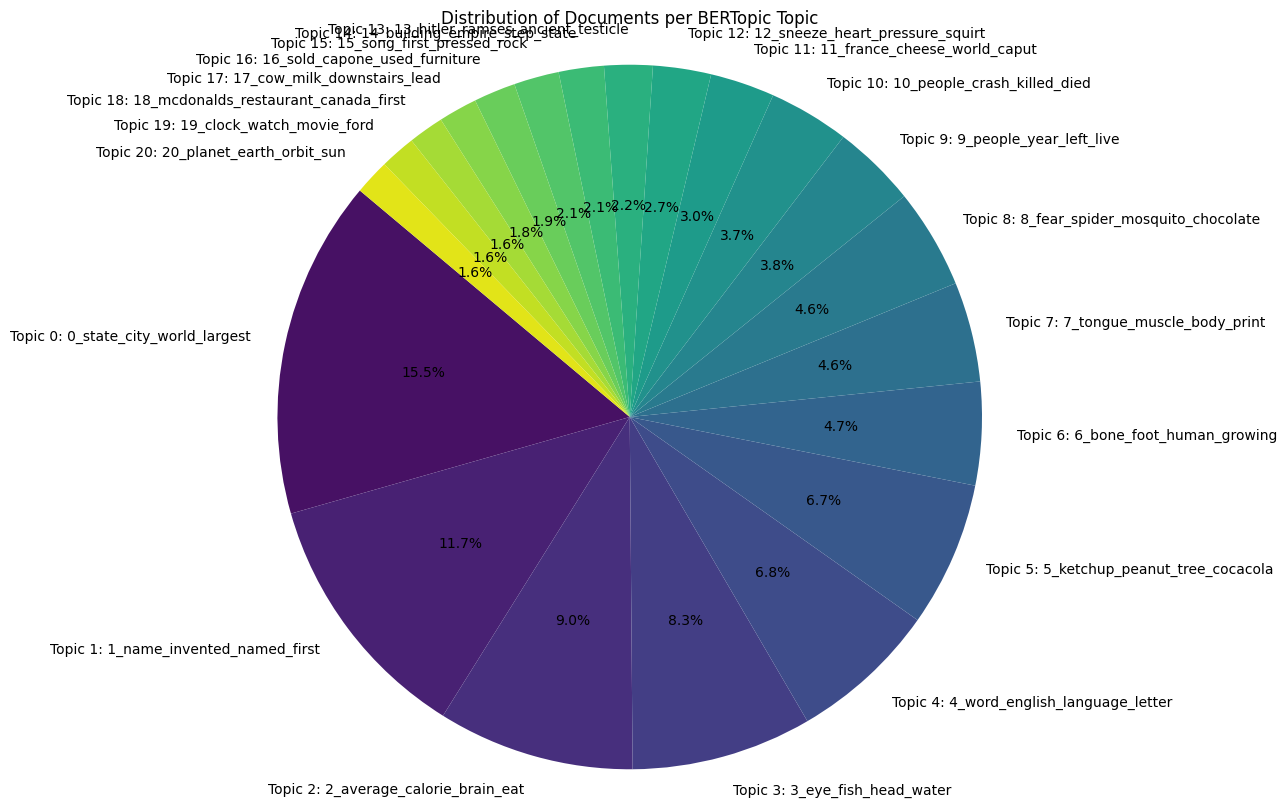

In [95]:
# Prepare data for pie chart
pie_labels = [f"Topic {row.Topic}: {row.Name}" for idx, row in topic_counts.iterrows()]
pie_values = topic_counts['Count'].values

plt.figure(figsize=(10, 10))
plt.pie(
    pie_values,
    labels=pie_labels,
    autopct='%1.1f%%', # Format percentage display
    startangle=140,
    colors=sns.color_palette('viridis', len(pie_labels))
)
plt.title('Distribution of Documents per BERTopic Topic')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()